Import function and read data

In [100]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sci
import pandas as pd

from define_pdf import *
from define_cdf import *
from define_cdf_inv import *
from define_get_statistics import *
from define_get_parameters import *
from ECDF import *

data = pd.DataFrame(columns=["p [bar]", "T [K]", "d [m]", "d_top [m]", "n [-]"])

for i in range(1, 31):
    with open(f"welltests//W{i}_welltest.txt") as f:
        lines = f.readlines()
        T = float(lines[6][-9:][1:8]) #temperature [K]
        p = float(lines[5][-9:][1:8]) #pressure [bar]
    
    log_i = np.loadtxt(f"welllogs//W{i}_welllogs.txt", skiprows=4)
    d = log_i[-1, 0] - log_i[0, 0] #reservoir thickness [m]
    d_top = log_i[0, 0] #reservoir top depth under ground level [m]
    n = np.mean(log_i[:, 1]) #porosity [-]
    
    data.loc[i-1] = [p, T, d, d_top, n]

display(data.head())

,p [bar],T [K],d [m],d_top [m],n [-]
0,190.657,339.194,82.15,1807.00,0.161835
1,204.845,341.336,126.02,1922.14,0.189198
2,198.011,342.076,107.07,1953.64,0.163787
3,210.697,346.547,181.79,2102.64,0.183000
4,211.411,341.225,122.67,1917.34,0.177893


Visualize data

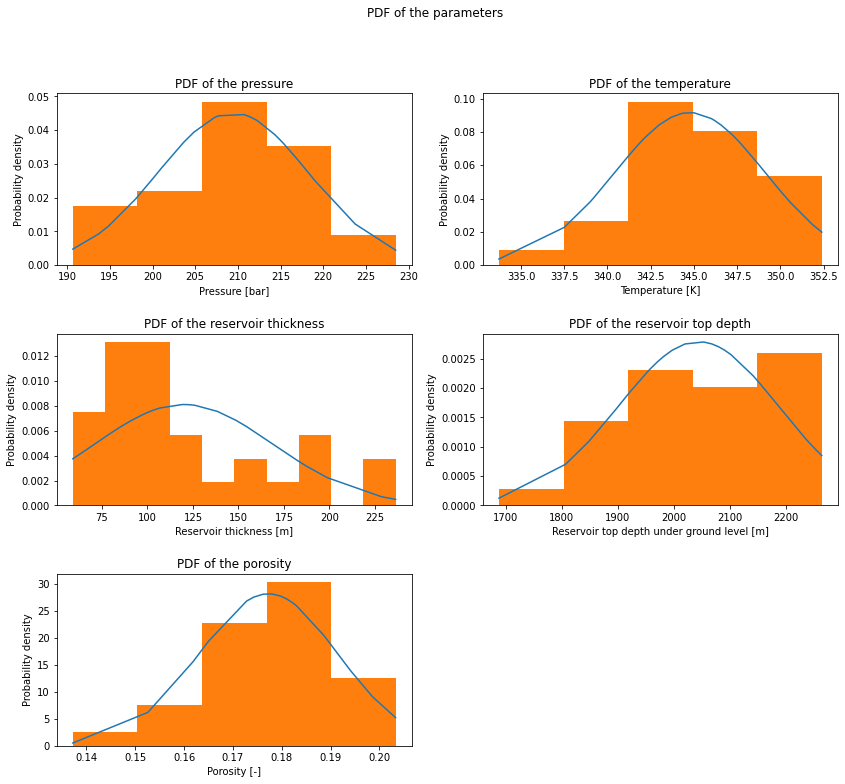

In [101]:
#PDF plots

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(14,12))
fig.suptitle('PDF of the parameters')
ax6.set_visible(False)

#Pressure

data = data.sort_values('p [bar]') ##sort pressure

pressure_pdf = pdf_norm(data['p [bar]'].to_list(), data['p [bar]'].mean(), data['p [bar]'].std()) ##pdf of pressure

ax1.plot(data['p [bar]'], pressure_pdf)
ax1.hist(data['p [bar]'], bins=5, density=True)

#Temperature

data = data.sort_values('T [K]') ##sort temperature

temperature_pdf = pdf_norm(data['T [K]'].to_list(), data['T [K]'].mean(), data['T [K]'].std()) ##pdf of temperature
ax2.plot(data['T [K]'], temperature_pdf)
ax2.hist(data['T [K]'], bins=5, density=True)

#Reservoir thickness

data = data.sort_values('d [m]') ##sort reservoir thickness

thickness_pdf = pdf_norm(data['d [m]'].to_list(), data['d [m]'].mean(),data['d [m]'].std()) ##pdf of reservoir thickness

ax3.plot(data['d [m]'], thickness_pdf)
ax3.hist(data['d [m]'], bins=10, density=True)

#Reservoir top depth

data = data.sort_values('d_top [m]') ##sort reservoir top depth

top_depth_pdf = pdf_norm(data['d_top [m]'].to_list(), data['d_top [m]'].mean(),data['d_top [m]'].std()) ##pdf of reservoir top depth

ax4.plot(data['d_top [m]'], top_depth_pdf)
ax4.hist(data['d_top [m]'], bins=5, density=True)

#Porosity

data = data.sort_values('n [-]') ##sort porosity

porosity_pdf = pdf_norm(data['n [-]'].to_list(), data['n [-]'].mean(),data['n [-]'].std()) ##pdf of porosity

ax5.plot(data['n [-]'], porosity_pdf)
ax5.hist(data['n [-]'], bins=5, density=True)

#Set titles and labels

ax1.set_title('PDF of the pressure')
ax1.set_xlabel('Pressure [bar]')
ax1.set_ylabel('Probability density')

ax2.set_title('PDF of the temperature')
ax2.set_xlabel('Temperature [K]')
ax2.set_ylabel('Probability density')

ax3.set_title('PDF of the reservoir thickness')
ax3.set_xlabel('Reservoir thickness [m]')
ax3.set_ylabel('Probability density')

ax4.set_title('PDF of the reservoir top depth')
ax4.set_xlabel('Reservoir top depth under ground level [m]')
ax4.set_ylabel('Probability density')

ax5.set_title('PDF of the porosity')
ax5.set_xlabel('Porosity [-]')
ax5.set_ylabel('Probability density')

fig.subplots_adjust(hspace=0.4)

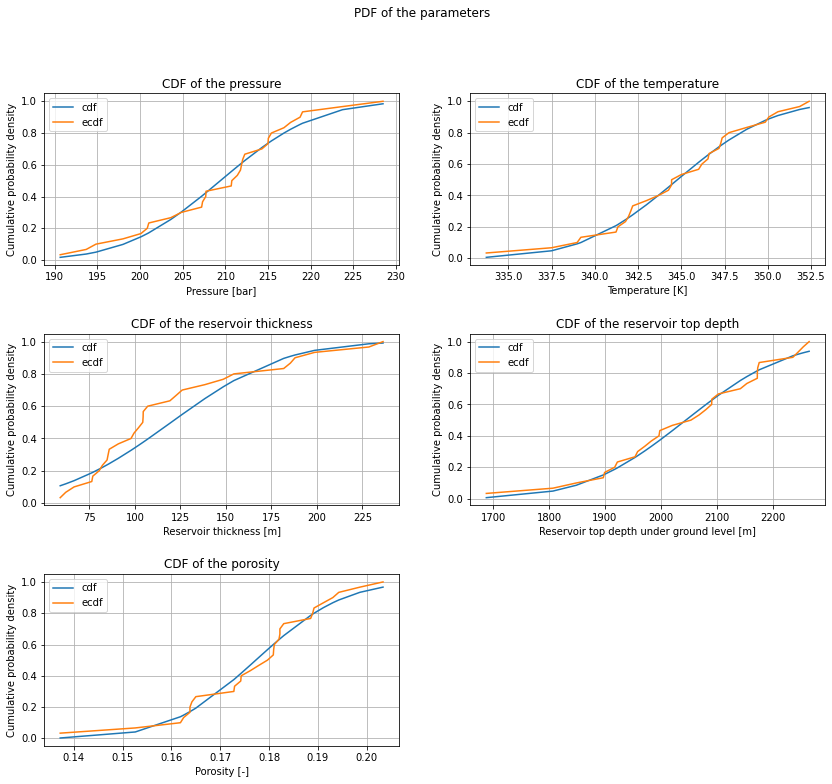

In [104]:
#CDF plots

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(14,12))
fig.suptitle('PDF of the parameters')
ax6.set_visible(False)

#Pressure

data = data.sort_values('p [bar]') ##sort pressure

pressure_cdf = cdf_norm(data['p [bar]'].to_list(), data['p [bar]'].mean(), data['p [bar]'].std()) ##cdf of pressure
pressure_ecdf, f = ecdf(data['p [bar]'])

ax1.plot(data['p [bar]'], pressure_cdf, label = 'cdf')
ax1.plot(pressure_ecdf, f, label = 'ecdf')

#Temperature

data = data.sort_values('T [K]') ##sort temperature

temperature_cdf = cdf_norm(data['T [K]'].to_list(), data['T [K]'].mean(), data['T [K]'].std()) ##cdf of temperature
temperature_ecdf, f = ecdf(data['T [K]'])

ax2.plot(data['T [K]'], temperature_cdf, label = 'cdf')
ax2.plot(temperature_ecdf, f, label = 'ecdf')

#Reservoir thickness

data = data.sort_values('d [m]') ##sort reservoir thickness

thickness_cdf = cdf_norm(data['d [m]'].to_list(), data['d [m]'].mean(),data['d [m]'].std()) ##cdf of reservoir thickness
thickness_ecdf, f = ecdf(data['d [m]'])

ax3.plot(data['d [m]'], thickness_cdf, label = 'cdf')
ax3.plot(thickness_ecdf, f, label = 'ecdf')

#Reservoir top depth

data = data.sort_values('d_top [m]') ##sort reservoir top depth

top_depth_cdf = cdf_norm(data['d_top [m]'].to_list(), data['d_top [m]'].mean(),data['d_top [m]'].std()) ##cdf of reservoir top depth
top_depth_ecdf, f = ecdf(data['d_top [m]'])


ax4.plot(data['d_top [m]'], init_depth_cdf, label = 'cdf')
ax4.plot(init_depth_ecdf, f, label = 'ecdf')

#Porosity

data = data.sort_values('n [-]') ##sort porosity

porosity_cdf = cdf_norm(data['n [-]'].to_list(), data['n [-]'].mean(),data['n [-]'].std()) ##cdf of porosity
porosity_ecdf, f = ecdf(data['n [-]'])

ax5.plot(data['n [-]'], porosity_cdf, label = 'cdf')
ax5.plot(porosity_ecdf, f, label = 'ecdf')

#Set titles and labels

ax1.set_title('CDF of the pressure')
ax1.set_xlabel('Pressure [bar]')
ax1.set_ylabel('Cumulative probability density')
ax1.legend()
ax1.grid()

ax2.set_title('CDF of the temperature')
ax2.set_xlabel('Temperature [K]')
ax2.set_ylabel('Cumulative probability density')
ax2.legend()
ax2.grid()

ax3.set_title('CDF of the reservoir thickness')
ax3.set_xlabel('Reservoir thickness [m]')
ax3.set_ylabel('Cumulative probability density')
ax3.legend()
ax3.grid()

ax4.set_title('CDF of the reservoir top depth')
ax4.set_xlabel('Reservoir top depth under ground level [m]')
ax4.set_ylabel('Cumulative probability density')
ax4.legend()
ax4.grid()

ax5.set_title('CDF of the porosity')
ax5.set_xlabel('Porosity [-]')
ax5.set_ylabel('Cumulative probability density')
ax5.legend()
ax5.grid()

fig.subplots_adjust(hspace=0.4)

From plotting the histograms we observed that our variables are more accuratly described by normal distribution. We also tried to fit a gumbel but the results with normal distribution were more accurate. Moreover, for the reservoir depth we tried the exponential function as well but it was not describing the first largest values well. Our distribution choices were also validated empirically by plotting the CDF and ECDF plots where all variables follow each other closely.